# Retail Demand Forecasting Capstone

## Backtested Forecasting of Daily Store-Item Demand

This project develops and evaluates forecasting models for daily retail demand using the Store Item Demand Forecasting dataset.

the data is fetched from Kaggle's forecasting competetion @
https://www.kaggle.com/competitions/demand-forecasting-kernels-only/data

The analysis focuses on **Store 1, Item 1** and compares classical statistical forecasting, tree-based machine learning, and probabilistic forecasting approaches.

The project uses time-aware validation throughout so that every forecast is generated using only information that would have been available at the forecast origin.

The main objectives are to:

- analyse trend, seasonality, autocorrelation, and stationarity;
- fit and compare classical forecasting models;
- build a LightGBM forecasting model using lag, rolling, and calendar features;
- evaluate models using walk-forward backtesting;
- compare expanding and rolling training windows;
- benchmark models against a seasonal-naive forecast;
- evaluate both point forecasts and prediction intervals;
- and recommend an appropriate forecasting approach based on accuracy, stability, uncertainty, interpretability, and computational requirements.

## Imported Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf
)
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import lightgbm as lgb
from backtest import run_backtest
from metrics import (
    mae,
    rmse,
    mase
)
from prophet import Prophet

from sktime.forecasting.theta import (
    ThetaForecaster
)

from sklearn.metrics import (
    mean_pinball_loss
)
import warnings
warnings.filterwarnings("ignore")


Importing plotly failed. Interactive plots will not work.


# 1. Data Loading and Validation

The dataset contains daily sales observations across multiple stores and items.

The full dataset contains **913,000 observations**, covering **10 stores** and **50 items**. For this capstone, a single time series is selected so that all forecasting methods can be compared consistently.

The forecasting target is:

**Daily sales for Store 1, Item 1.**

Before modelling, the selected series is checked for:

- missing observations;
- duplicate dates;
- chronological ordering;
- missing calendar dates;
- and appropriate daily frequency.

since lag-based and seasonal forecasting methods depend on observations being correctly ordered and equally spaced through time; the steps above are taken.

In [2]:
df = pd.read_csv("train.csv", parse_dates=["date"]
)

In [3]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    913000 non-null  datetime64[ns]
 1   store   913000 non-null  int64         
 2   item    913000 non-null  int64         
 3   sales   913000 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 27.9 MB


In [5]:
for i in df.columns: 
    if i != "date": 
        print(i, "has this many uniques", df[i].nunique())

store has this many uniques 10
item has this many uniques 50
sales has this many uniques 213


In [6]:
print("we will be looking at store one and item 1 for this prediction and analysis")
df2 = df[
    (df["store"] == 1) &
    (df["item"] == 1)
].copy()

we will be looking at store one and item 1 for this prediction and analysis


In [7]:
df2 = df2.sort_values("date").reset_index(drop=True)

print("Number of observations:", len(df2))
print("Start date:", df2["date"].min())
print("End date:", df2["date"].max())

print("\nMissing values:")
print(df2.isnull().sum())

print("\nDuplicate dates:")
print(df2["date"].duplicated().sum())

expected_dates = pd.date_range(
    start=df2["date"].min(),
    end=df2["date"].max(),
    freq="D"
)

missing_dates = expected_dates.difference(df2["date"])

print("\nMissing dates:", len(missing_dates))

Number of observations: 1826
Start date: 2013-01-01 00:00:00
End date: 2017-12-31 00:00:00

Missing values:
date     0
store    0
item     0
sales    0
dtype: int64

Duplicate dates:
0

Missing dates: 0


## 1.1 Data Quality

The selected Store 1, Item 1 series contains **1,826 daily observations**, covering the period from **1 January 2013 to 31 December 2017**.

No missing values, duplicate dates, or missing calendar days were identified. The series therefore provides a complete daily sequence suitable for time-series modelling.

The target variable is `sales`, and the forecasting frequency is daily.

# 2. Time Series Structure and Diagnostics

Before fitting forecasting models, the structure of the sales series is examined.

The diagnostic analysis investigates:

- long-term trend;
- weekly and annual seasonality;
- autocorrelation;
- partial autocorrelation;
- stationarity;
- and whether differencing is justified.

These diagnostics will later guide the specification of the classical forecasting models and the feature engineering used for LightGBM.

<Axes: xlabel='date', ylabel='sales'>

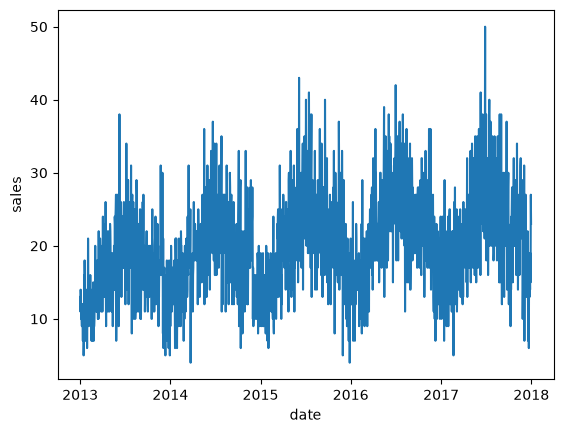

In [8]:
sns.lineplot(data=df2, x="date", y="sales")

## 2.1 Initial Time-Series Inspection

The daily sales series shows clear systematic variation through time.

Sales generally increase across the five-year sample, suggesting a long-term upward trend. Repeating rises and falls are also visible within each year, indicating substantial seasonal behaviour.

The regularity of these patterns suggests that forecasting methods capable of representing trend and seasonality may be appropriate. Formal decomposition and autocorrelation analysis are therefore used to examine this structure in greater detail.

In [9]:
series = (
    df2
    .set_index("date")["sales"]
    .asfreq("D")
)

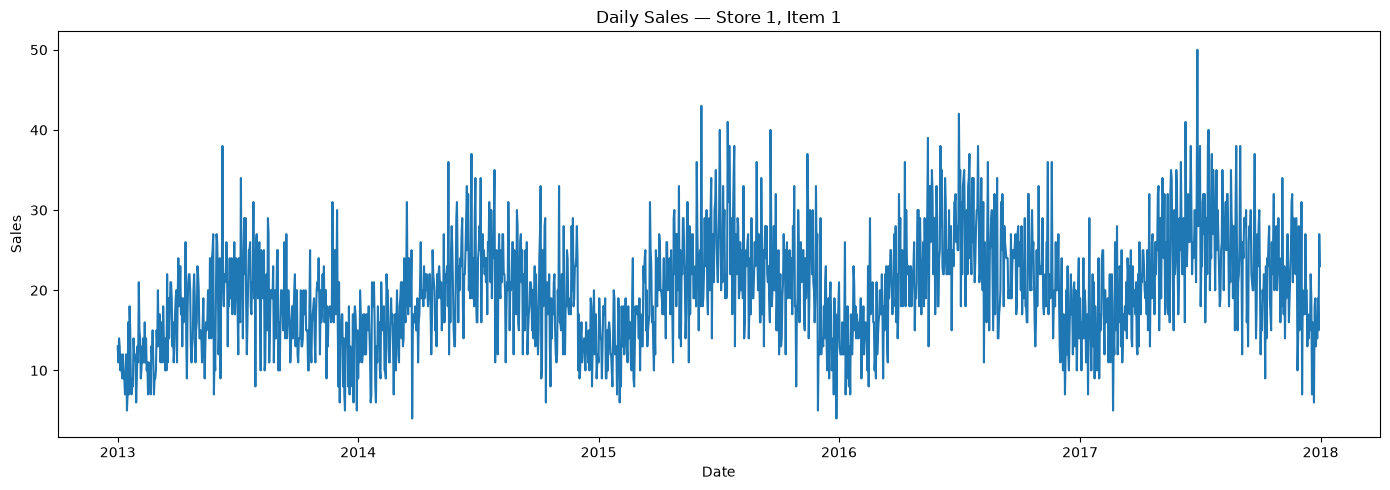

In [10]:
plt.figure(figsize=(14, 5))

plt.plot(series)

plt.title("Daily Sales — Store 1, Item 1")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

## 2.2 Weekly Seasonal Decomposition

STL decomposition is first performed using a seasonal period of **7 days**.

Because the observations are daily, a seven-observation cycle represents one calendar week. This decomposition separates the observed series into:

- trend;
- weekly seasonal variation;
- and residual variation.

The purpose is to determine whether demand systematically changes according to the day of the week.

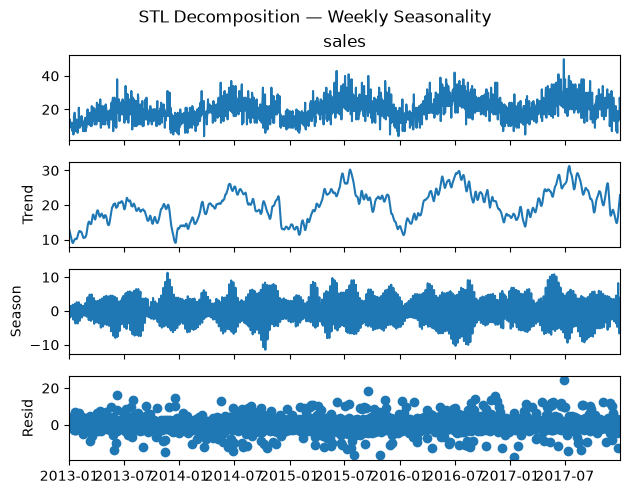

In [11]:
stl_weekly = STL(
    series,
    period=7,
    robust=True
)

weekly_result = stl_weekly.fit()

weekly_result.plot()

plt.suptitle(
    "STL Decomposition — Weekly Seasonality",
    y=1.02
)

plt.show()

### Weekly Decomposition Interpretation

The weekly STL decomposition reveals a recurring seven-day seasonal component.

The trend component still contains substantial longer-term variation because removing a seven-day cycle does not remove the slower annual behaviour visible in the original series.

The residual component contains the remaining variation that is not explained by the estimated trend and weekly seasonal pattern.

The presence of a recurring weekly component provides an initial reason to investigate weekly seasonal lags during the autocorrelation analysis.

## 2.3 Annual Seasonal Decomposition

A second STL decomposition is performed using a seasonal period of **365 days**.

This decomposition is used to investigate whether the broad rise-and-fall pattern visible across individual years represents recurring annual seasonality rather than only long-term trend.

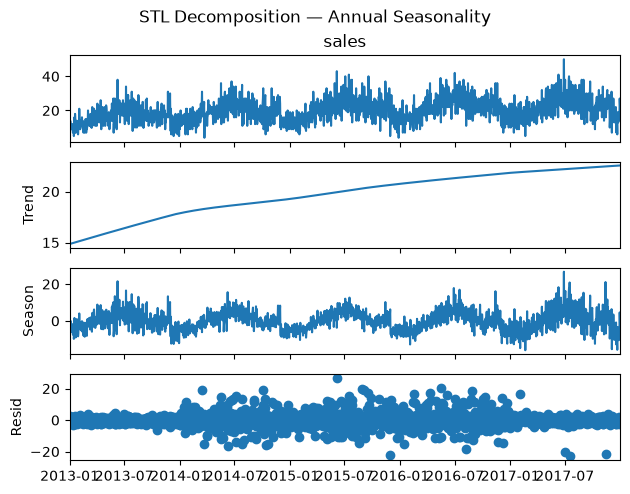

In [12]:
stl_yearly = STL(
    series,
    period=365,
    robust=True
)

yearly_result = stl_yearly.fit()

yearly_result.plot()

plt.suptitle(
    "STL Decomposition — Annual Seasonality",
    y=1.02
)

plt.show()

### Annual Decomposition Interpretation

The annual decomposition provides evidence of substantial longer-term seasonal structure.

The trend component shows an overall increase in the underlying level of demand across the sample, while the annual seasonal component captures a recurring pattern within each year.

Together, the weekly and annual decompositions indicate that this retail series contains more than one seasonal timescale. Weekly seasonality is especially important for the short-horizon models used later in the project.

## 2.4 ACF and PACF Analysis

The ACF is used to measure the relationship between current sales and sales observed at previous lags.

The PACF measures the relationship between the current value and an individual lag after accounting for the intermediate lags.

Because the series is daily, particular attention is given to lags:

**7, 14, 21, 28, ...**

Repeated correlation peaks at these intervals would provide evidence of weekly seasonal dependence.

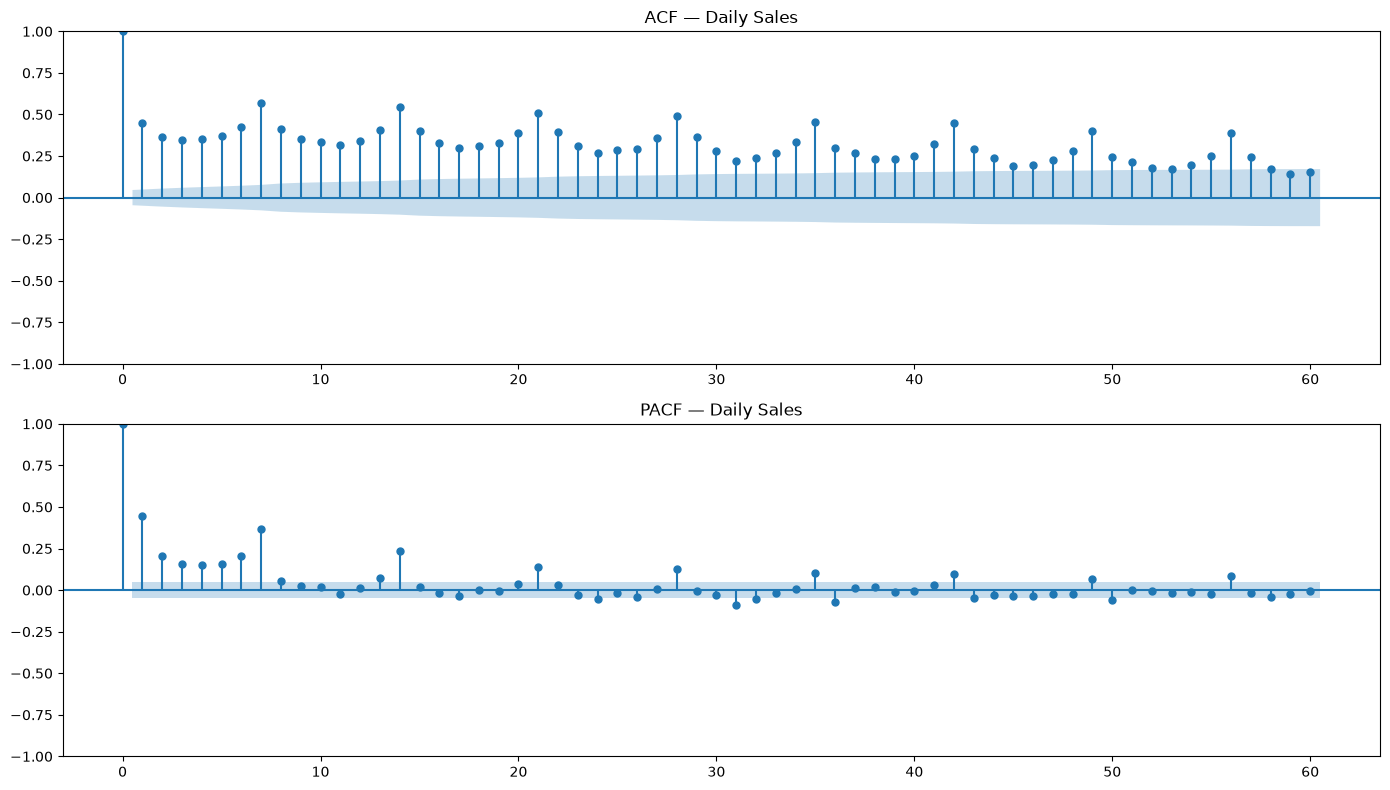

In [13]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8)
)

plot_acf(
    series.dropna(),
    lags=60,
    ax=axes[0]
)

axes[0].set_title(
    "ACF — Daily Sales"
)

plot_pacf(
    series.dropna(),
    lags=60,
    ax=axes[1],
    method="ywm"
)

axes[1].set_title(
    "PACF — Daily Sales"
)

plt.tight_layout()
plt.show()

### ACF and PACF Interpretation

The ACF shows substantial serial dependence together with recurring peaks at approximately seven-day intervals.

Noticeable peaks occur around lags 7, 14, 21, 28 and subsequent weekly multiples. Unlike a series where all neighbouring lags are uniformly high, these recurring weekly peaks provide evidence of a distinct weekly seasonal structure.

The PACF also shows meaningful short-lag relationships and seasonal behaviour.

These results support the later use of:

- weekly lag features;
- a seven-day seasonal-naive benchmark;
- and weekly seasonal components in classical forecasting models.

## 2.5 Longer-Term Autocorrelation

The ACF is also examined across approximately 400 days to investigate longer seasonal behaviour.

Extending the lag range beyond one year allows the weekly dependence to be viewed alongside the broader annual cycle identified by the STL decomposition.

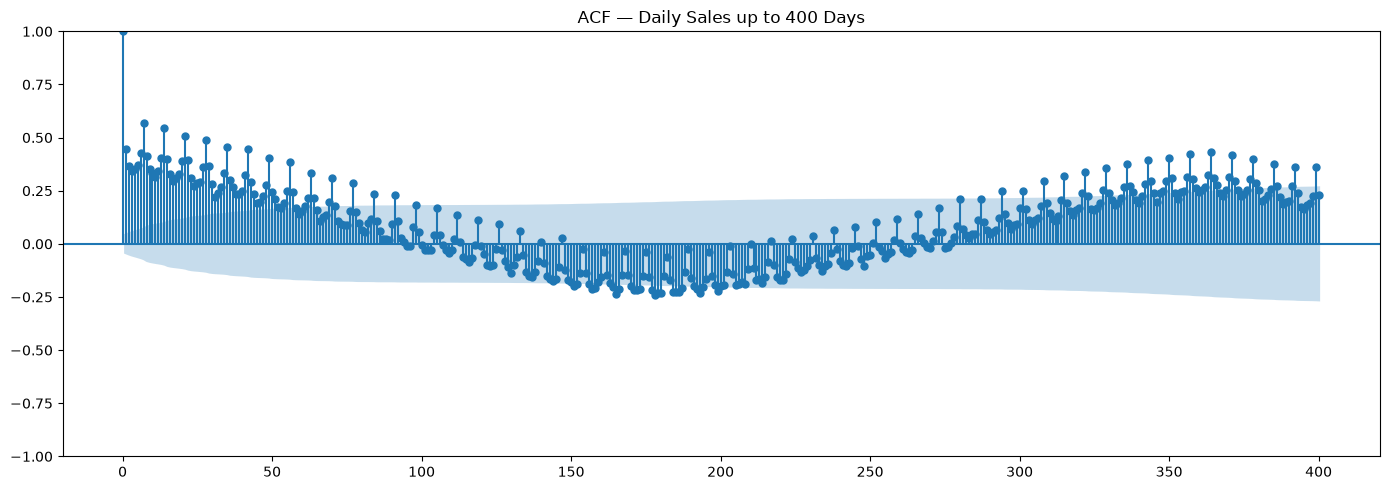

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))

plot_acf(
    series.dropna(),
    lags=400,
    ax=ax
)

ax.set_title(
    "ACF — Daily Sales up to 400 Days"
)

plt.tight_layout()
plt.show()

### Longer-Term Autocorrelation Interpretation

The longer-lag ACF shows a broad cyclical pattern across the year, providing additional evidence of annual seasonal behaviour.

The correlation structure therefore supports the decomposition results: the series contains both strong weekly dependence and slower annual variation.

For computational tractability, the main short-term forecasting models will explicitly focus on the weekly seasonal period, while annual behaviour can also be represented through trend, calendar features, and the historical training data.

## 2.6 Stationarity Analysis

The ADF test is used to test for the presence of a unit root.

The null hypothesis is that the series contains a unit root and is therefore non-stationary in this sense.

A significance level of **5%** is used:

- if the p-value is below 0.05, the null hypothesis is rejected;
- if the p-value is above 0.05, there is insufficient evidence to reject the unit-root hypothesis.

The result is used to determine whether ordinary differencing is justified rather than applying differencing automatically.

In [15]:
def run_adf(series, name):

    result = adfuller(
        series.dropna(),
        result_object=False
    )

    print(name)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    print("\nCritical Values:")

    for key, value in result[4].items():
        print(f"{key}: {value}")

In [16]:
run_adf(
    series,
    "Store 1 — Item 1 Daily Sales"
)

Store 1 — Item 1 Daily Sales
ADF Statistic: -3.157670556332791
p-value: 0.022569380626572377

Critical Values:
1%: -3.4339840952648695
5%: -2.8631452508003057
10%: -2.567624583142913


### ADF Result

The ADF test on the original daily sales series produced:

- **ADF statistic:** -3.158
- **p-value:** 0.023
- **5% critical value:** approximately -2.863

Because the p-value is below 0.05 and the test statistic is more negative than the 5% critical value, the null hypothesis of a unit root is rejected at the 5% significance level.

The result therefore provides evidence against a unit root in the original series. Ordinary first differencing is not required solely to satisfy this stationarity test.

However, the STL decomposition and ACF show pronounced weekly seasonal dependence. A seven-day seasonal difference is therefore investigated separately.

## 2.7 Seasonal Differencing

Weekly seasonal differencing is calculated as:

\[
y_t - y_{t-7}
\]

This compares the current observation with the observation from the same point in the previous weekly cycle.

Seasonal differencing is examined because the diagnostic analysis identified strong dependence at weekly multiples, not because the original ADF test required ordinary first differencing.

In [17]:
seasonal_diff_7 = (
    series
    .diff(7)
    .dropna()
)

In [18]:
run_adf(
    seasonal_diff_7,
    "7-Day Seasonally Differenced Sales"
)

7-Day Seasonally Differenced Sales
ADF Statistic: -8.944407360067894
p-value: 9.070149410051775e-15

Critical Values:
1%: -3.4340003240943844
5%: -2.8631524150111547
10%: -2.567628397867784


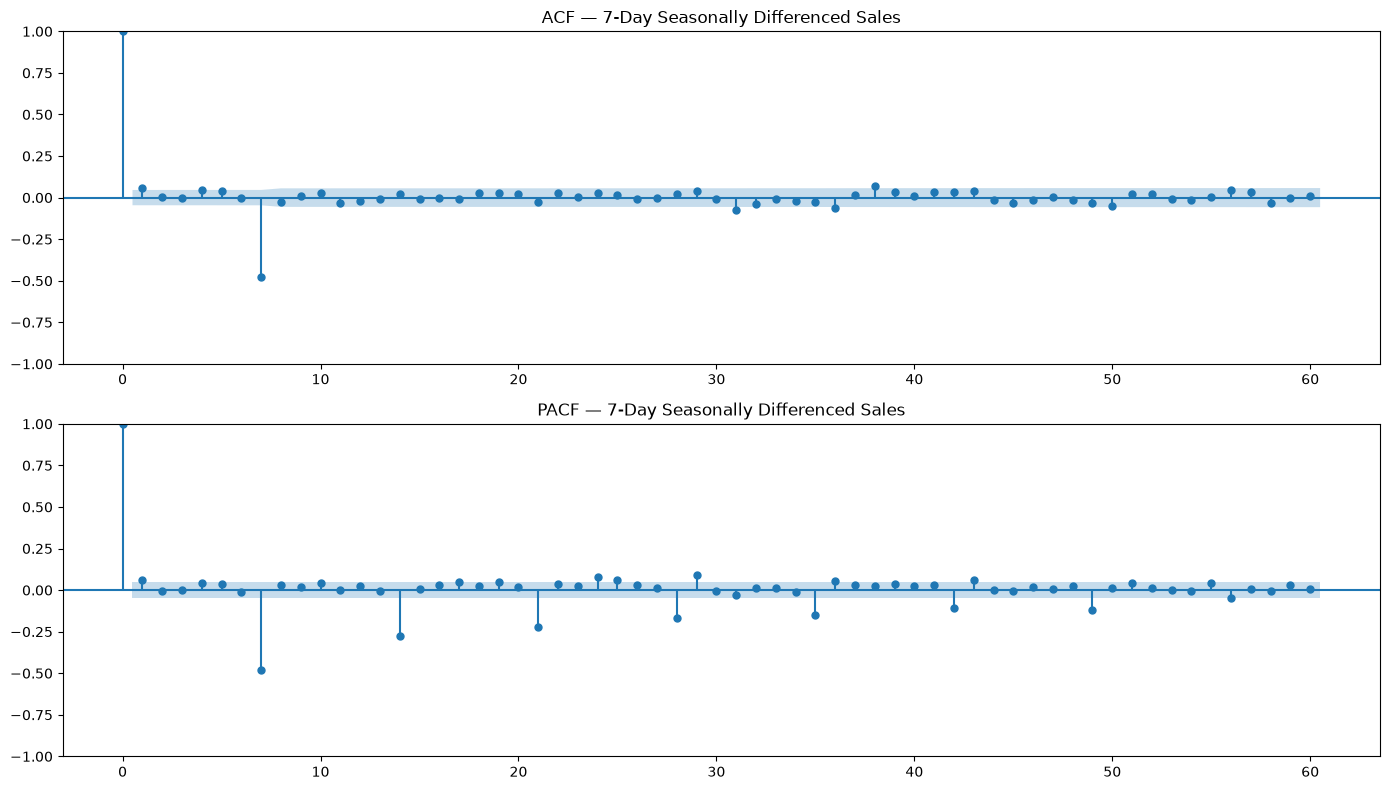

In [19]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8)
)

plot_acf(
    seasonal_diff_7,
    lags=60,
    ax=axes[0]
)

axes[0].set_title(
    "ACF — 7-Day Seasonally Differenced Sales"
)

plot_pacf(
    seasonal_diff_7,
    lags=60,
    ax=axes[1],
    method="ywm"
)

axes[1].set_title(
    "PACF — 7-Day Seasonally Differenced Sales"
)

plt.tight_layout()
plt.show()

### Seasonal Differencing Results

After applying a seven-day seasonal difference, the ADF test produced:

- **ADF statistic:** -8.944
- **p-value:** < 0.001

This provides strong evidence against a unit root in the seasonally differenced series.

The ACF of the seasonally differenced data shows a pronounced negative correlation at lag 7, together with smaller recurring correlations at later weekly multiples.

This demonstrates that seasonal differencing substantially alters the weekly dependence. However, because the original series already passed the ADF test and seasonal differencing introduces strong negative seasonal autocorrelation, seasonal differencing is not automatically assumed to be necessary.

Classical models with alternative seasonal specifications will therefore be compared empirically rather than selecting a differencing configuration solely from the diagnostic plots.

# 3. Classical Forecasting Models

Classical forecasting methods are evaluated first.

The analysis includes:

1. ARIMA/SARIMAX candidate models;
2. model selection using AIC and BIC;
3. exponential smoothing;
4. and residual diagnostics using the Ljung-Box test.

Rather than selecting a single model order arbitrarily, multiple plausible configurations are fitted and compared.

## 3.1 ARIMA/SARIMAX Model Selection

The diagnostic analysis provides guidance for candidate model construction but does not uniquely determine the final specification.

Because strong weekly seasonality is present, SARIMAX configurations with a seasonal period of 7 are considered alongside simpler specifications.

Candidate models are compared using AIC and BIC. Both criteria reward model fit while penalising unnecessary complexity. Lower values indicate a preferred balance between fit and complexity within the set of models being compared.

In [20]:
candidate_models = [
    # No seasonal AR/MA terms
    ((0, 0, 0), (0, 0, 0, 7)),
    ((1, 0, 0), (0, 0, 0, 7)),
    ((0, 0, 1), (0, 0, 0, 7)),
    ((1, 0, 1), (0, 0, 0, 7)),
    
    # Weekly seasonal terms, no seasonal differencing
    ((1, 0, 0), (1, 0, 0, 7)),
    ((1, 0, 0), (0, 0, 1, 7)),
    ((0, 0, 1), (1, 0, 0, 7)),
    ((0, 0, 1), (0, 0, 1, 7)),
    ((1, 0, 1), (1, 0, 1, 7)),
    
    # Weekly seasonal differencing
    ((1, 0, 0), (0, 1, 1, 7)),
    ((0, 0, 1), (0, 1, 1, 7)),
    ((1, 0, 1), (0, 1, 1, 7)),
]

In [21]:
sarimax_results = []

for order, seasonal_order in candidate_models:
    
    try:
        model = SARIMAX(
            series,
            order=order,
            seasonal_order=seasonal_order,
            trend="c",
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        
        fitted_model = model.fit(
            disp=False,
            maxiter=200
        )
        
        sarimax_results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": fitted_model.aic,
            "BIC": fitted_model.bic,
            "converged": fitted_model.mle_retvals["converged"]
        })
        
    except Exception as e:
        print(
            f"Model failed: {order} {seasonal_order}"
        )
        print(e)

In [22]:
sarimax_comparison = pd.DataFrame(
    sarimax_results
)

sarimax_comparison = (
    sarimax_comparison
    .sort_values("AIC")
    .reset_index(drop=True)
)

sarimax_comparison

,order,seasonal_order,AIC,BIC,converged
0,"(1, 0, 1)","(0, 1, 1, 7)",10745.961736,10773.467147,True
1,"(1, 0, 0)","(0, 1, 1, 7)",11002.649325,11024.655863,True
2,"(0, 0, 1)","(0, 1, 1, 7)",11004.801823,11026.806152,True
3,"(1, 0, 1)","(1, 0, 1, 7)",11029.490777,11062.520429,True
4,"(1, 0, 0)","(1, 0, 0, 7)",11323.401376,11345.423345,True
5,"(1, 0, 1)","(0, 0, 0, 7)",11335.660659,11357.695807,True
6,"(0, 0, 1)","(1, 0, 0, 7)",11342.305283,11364.329452,True
7,"(1, 0, 0)","(0, 0, 1, 7)",11495.237845,11517.259815,True
8,"(0, 0, 1)","(0, 0, 1, 7)",11548.479556,11570.499324,True
9,"(1, 0, 0)","(0, 0, 0, 7)",11740.807263,11757.335268,True


In [23]:
best_aic = sarimax_comparison.loc[
    sarimax_comparison["AIC"].idxmin()
]

best_bic = sarimax_comparison.loc[
    sarimax_comparison["BIC"].idxmin()
]

print("Best model by AIC")
print(best_aic)

print("\nBest model by BIC")
print(best_bic)
warnings.filterwarnings("default")

Best model by AIC
order                (1, 0, 1)
seasonal_order    (0, 1, 1, 7)
AIC               10745.961736
BIC               10773.467147
converged                 True
Name: 0, dtype: object

Best model by BIC
order                (1, 0, 1)
seasonal_order    (0, 1, 1, 7)
AIC               10745.961736
BIC               10773.467147
converged                 True
Name: 0, dtype: object


### SARIMAX Candidate Results

Multiple SARIMAX specifications were compared using AIC and BIC.

Both criteria selected:

**SARIMAX(1,0,1)(0,1,1,7)**

with:

- **AIC:** 10745.961735
- **BIC:** 10773.467146

The fitted model successfully converged.

The selected specification contains a first-order non-seasonal
autoregressive component, a first-order non-seasonal moving-average
component, weekly seasonal differencing, and a first-order seasonal
moving-average component.

The agreement between AIC and BIC provides a clear preferred
specification among the candidate models evaluated. However, this
selection is based on in-sample information criteria and does not
establish that the model will provide the best out-of-sample forecast.

The selected model will therefore undergo residual diagnostics and
later be evaluated using walk-forward backtesting.

## 3.2 Selected SARIMAX Model and Residual Diagnostics

The candidate comparison selected
**SARIMAX(1,0,1)(0,1,1,7)** using both AIC and BIC.

The selected specification is now fitted explicitly so that its
residuals can be examined.

A forecasting model should ideally leave residuals that behave
approximately like unpredictable noise. If substantial autocorrelation
remains in the residuals, the model has not captured all of the
time-dependent structure in the series.

In [24]:
selected_sarimax = SARIMAX(
    series,
    order=(1, 0, 1),
    seasonal_order=(0, 1, 1, 7),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

selected_sarimax_fit = selected_sarimax.fit(
    disp=False,
    maxiter=200
)

print(selected_sarimax_fit.summary())

                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1826
Model:             SARIMAX(1, 0, 1)x(0, 1, 1, 7)   Log Likelihood               -5367.981
Date:                           Mon, 21 Sep 2026   AIC                          10745.962
Time:                                   20:00:00   BIC                          10773.467
Sample:                               01-01-2013   HQIC                         10756.112
                                    - 12-31-2017                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0001      0.000      0.494      0.622      -0.000       0.001
ar.L1          0.9903      0.004    246.613

### Ljung-Box Residual Test

The Ljung-Box test evaluates whether the residual autocorrelations are
jointly different from zero.

The null hypothesis is that the residuals contain no significant
autocorrelation up to the specified lag.

Tests are performed at lags 7, 14, 21, and 28 because the earlier
diagnostic analysis identified weekly dependence as an important
feature of the series.

A p-value below 0.05 indicates evidence that serial dependence remains
in the residuals.

In [25]:
sarimax_residuals = pd.Series(
    selected_sarimax_fit.resid,
    index=series.index
)

burn = selected_sarimax_fit.loglikelihood_burn

sarimax_residuals_clean = (
    sarimax_residuals
    .iloc[burn:]
    .dropna()
)

ljung_box_results = acorr_ljungbox(
    sarimax_residuals_clean,
    lags=[7, 14, 21, 28],
    return_df=True
)

ljung_box_results

,lb_stat,lb_pvalue
7,4.404301,0.732208
14,9.240404,0.815349
21,12.598704,0.922029
28,20.726786,0.836553


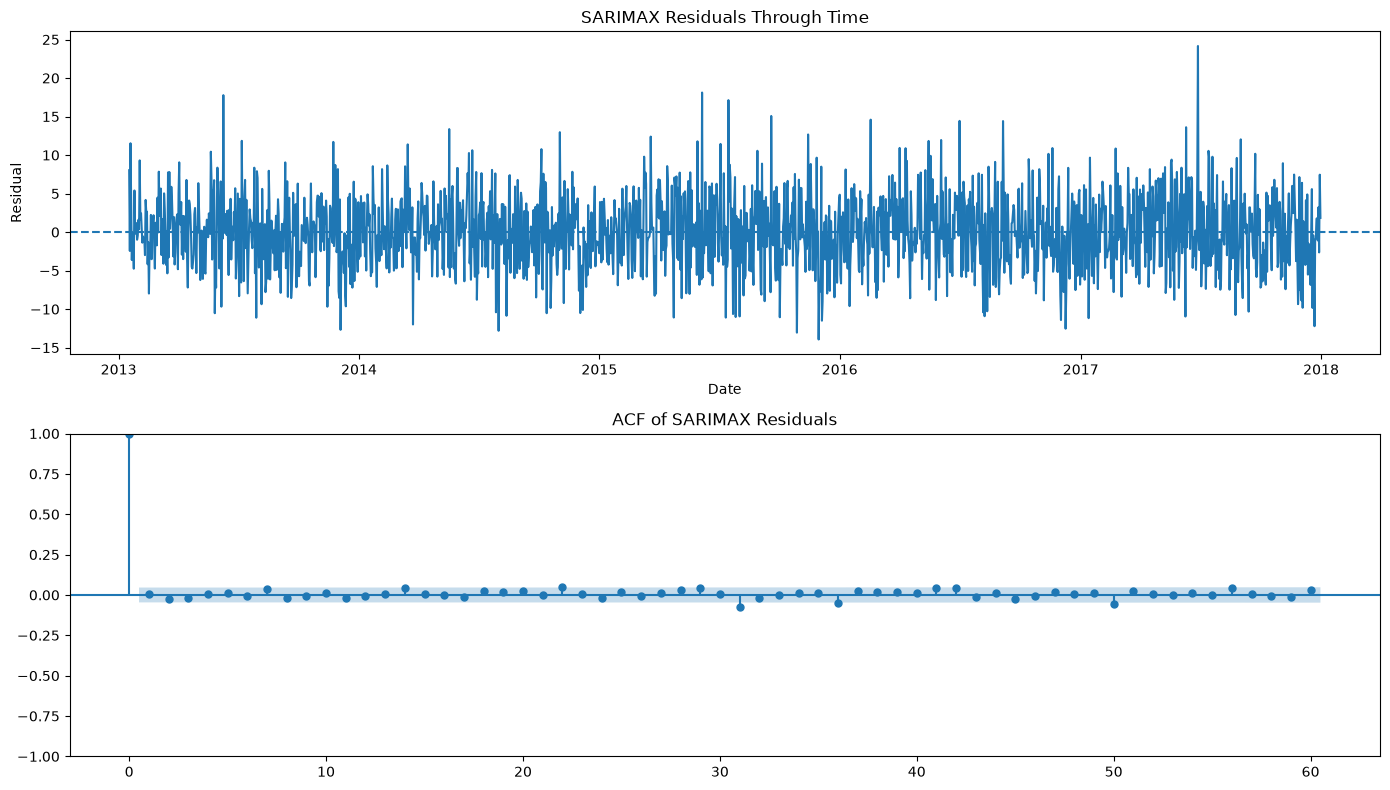

In [26]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 8)
)

axes[0].plot(
    sarimax_residuals_clean
)

axes[0].axhline(
    0,
    linestyle="--"
)

axes[0].set_title(
    "SARIMAX Residuals Through Time"
)

axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residual")

plot_acf(
    sarimax_residuals_clean,
    lags=60,
    ax=axes[1]
)

axes[1].set_title(
    "ACF of SARIMAX Residuals"
)

plt.tight_layout()
plt.show()

### SARIMAX Residual Diagnostic Results

The Ljung-Box test produced p-values of:

- **Lag 7:** 0.732
- **Lag 14:** 0.815
- **Lag 21:** 0.922
- **Lag 28:** 0.837

All p-values are above the 0.05 significance threshold. Therefore,
there is insufficient evidence to reject the null hypothesis of no
residual autocorrelation at the tested weekly horizons.

The residual ACF is also largely concentrated around zero, supporting
the conclusion that the selected SARIMAX model has captured most of
the systematic serial dependence assessed by these diagnostics.

These results support the adequacy of the model's residual structure,
although its forecasting performance must still be evaluated using
out-of-sample walk-forward backtesting.

## 3.3 Exponential Smoothing

Exponential smoothing provides a second classical forecasting family.

Where SARIMAX represents temporal dependence using autoregressive,
moving-average, differencing, and seasonal terms, exponential
smoothing models the evolution of components such as level, trend,
and seasonality directly.

Because the earlier analysis identified a trend and strong weekly
seasonality, Holt-Winters configurations with a seasonal period of
seven days are evaluated.

In [27]:
ets_candidates = [
    {
        "name": "Additive trend + additive seasonality",
        "trend": "add",
        "seasonal": "add",
        "damped_trend": False
    },
    {
        "name": "Damped additive trend + additive seasonality",
        "trend": "add",
        "seasonal": "add",
        "damped_trend": True
    },
    {
        "name": "No trend + additive seasonality",
        "trend": None,
        "seasonal": "add",
        "damped_trend": False
    }
]

In [28]:
ets_results = []
ets_fitted_models = {}

for config in ets_candidates:
    
    model = ExponentialSmoothing(
        series,
        trend=config["trend"],
        seasonal=config["seasonal"],
        seasonal_periods=7,
        damped_trend=config["damped_trend"],
        initialization_method="estimated"
    )
    
    fitted = model.fit(
        optimized=True
    )
    
    ets_fitted_models[
        config["name"]
    ] = fitted
    
    ets_results.append({
        "model": config["name"],
        "AIC": fitted.aic,
        "BIC": fitted.bic,
        "SSE": fitted.sse
    })

ets_comparison = (
    pd.DataFrame(ets_results)
    .sort_values("AIC")
    .reset_index(drop=True)
)

ets_comparison

,model,AIC,BIC,SSE
0,No trend + additive seasonality,5626.193888,5675.782835,39386.685595
1,Damped additive trend + additive seasonality,5629.673280,5695.791876,39332.353776
2,Additive trend + additive seasonality,5630.118511,5690.727225,39385.059770


In [29]:
best_ets_name = ets_comparison.loc[
    ets_comparison["AIC"].idxmin(),
    "model"
]

best_ets_fit = ets_fitted_models[
    best_ets_name
]

print("Selected Exponential Smoothing Model:")
print(best_ets_name)

print("\nAIC:", best_ets_fit.aic)
print("BIC:", best_ets_fit.bic)
print("SSE:", best_ets_fit.sse)

Selected Exponential Smoothing Model:
No trend + additive seasonality

AIC: 5626.193887575247
BIC: 5675.782835125641
SSE: 39386.685595033516


### Exponential Smoothing Model Selection

Three Holt-Winters configurations were evaluated using a weekly
seasonal period of seven days.

Both AIC and BIC selected:

**No trend + additive seasonality**

with:

- **AIC:** 5626.194
- **BIC:** 5675.783
- **SSE:** 39386.686

The damped-trend specification achieved a slightly lower SSE but had
higher AIC and BIC values. This illustrates the complexity penalty
incorporated into the information criteria: the additional trend
component did not improve the fit sufficiently to justify the more
complex specification.

Although the original series exhibits longer-term movement, this result
indicates that an explicit trend component was not preferred among the
evaluated exponential-smoothing specifications.

The selected exponential-smoothing model will later be compared with
SARIMAX and the machine-learning models using identical out-of-sample
walk-forward backtesting. Its AIC and BIC values are not used as a
direct cross-family comparison with SARIMAX.

# 4. LightGBM Forecasting and Feature Engineering

LightGBM is a tree-based machine-learning model and does not inherently
understand the chronological ordering of a time series.

Temporal information must therefore be represented explicitly through
features constructed from the historical observations.

The forecasting features used here include lagged sales, rolling
statistics, and calendar variables. These features are motivated by the
weekly and annual patterns identified during the earlier diagnostic
analysis.

The model fitted in this section establishes the machine-learning
forecasting pipeline. Its forecasting performance will be evaluated
later using the same walk-forward backtesting framework as the
classical models.

In [30]:
ml_df = (df2[["date", "sales"]].copy().sort_values("date").reset_index(drop=True))

## 4.1 Lag Features

Lag features provide historical observations directly to the model.

The earlier ACF analysis identified strong weekly dependence, so lags
at weekly multiples are included alongside shorter-term lags.

A 365-day lag is also included because the decomposition and longer-lag
ACF identified annual structure.

In [31]:
lag_values = [
    1,
    2,
    3,
    7,
    14,
    28,
    365
]

for lag in lag_values:
    ml_df[f"sales_lag_{lag}"] = (
        ml_df["sales"].shift(lag)
    )

## 4.2 Rolling-Window Features

Rolling statistics summarise recent demand behaviour rather than
representing only individual historical observations.

Rolling means provide information about the recent demand level, while
rolling standard deviations describe recent variability.

The target series is shifted by one day before calculating each rolling
statistic. This ensures that the current day's sales value is not
included in a feature used to predict that same day's sales.

In [32]:
past_sales = ml_df["sales"].shift(1)

for window in [7, 14, 28]:
    ml_df[f"rolling_mean_{window}"] = (
        past_sales
        .rolling(window=window)
        .mean()
    )

for window in [7, 28]:
    ml_df[f"rolling_std_{window}"] = (
        past_sales
        .rolling(window=window)
        .std()
    )

## 4.3 Calendar Features

Calendar variables provide information that is known in advance at the
time a forecast is made.

Day-of-week features allow the model to learn the strong weekly pattern
identified in the diagnostic analysis. Month and day-of-year variables
provide information about longer seasonal behaviour, while a weekend
indicator allows weekend demand to differ from weekday demand.

In [33]:
ml_df["day_of_week"] = (
    ml_df["date"].dt.dayofweek
)

ml_df["month"] = (
    ml_df["date"].dt.month
)

ml_df["day_of_year"] = (
    ml_df["date"].dt.dayofyear
)

ml_df["is_weekend"] = (
    ml_df["day_of_week"]
    .isin([5, 6])
    .astype(int)
)

In [34]:
ml_df.tail()

,date,sales,sales_lag_1,sales_lag_2,sales_lag_3,sales_lag_7,sales_lag_14,sales_lag_28,sales_lag_365,rolling_mean_7,rolling_mean_14,rolling_mean_28,rolling_std_7,rolling_std_28,day_of_week,month,day_of_year,is_weekend
1821,2017-12-27,14,16.0,13.0,19.0,16.0,17.0,28.0,10.0,14.285714,15.000000,17.071429,4.423961,5.715013,2,12,361,0
1822,2017-12-28,19,14.0,16.0,13.0,12.0,14.0,15.0,16.0,14.000000,14.785714,16.571429,4.358899,5.322409,3,12,362,0
1823,2017-12-29,15,19.0,14.0,16.0,6.0,16.0,19.0,21.0,15.000000,15.142857,16.714286,4.618802,5.332341,4,12,363,0
1824,2017-12-30,27,15.0,19.0,14.0,18.0,15.0,16.0,24.0,16.285714,15.071429,16.571429,2.429972,5.322409,5,12,364,1
1825,2017-12-31,23,27.0,15.0,19.0,19.0,22.0,31.0,14.0,17.571429,15.928571,16.964286,4.755949,5.673082,6,12,365,1


In [35]:
feature_columns = [
    "sales_lag_1",
    "sales_lag_2",
    "sales_lag_3",
    "sales_lag_7",
    "sales_lag_14",
    "sales_lag_28",
    "sales_lag_365",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7",
    "rolling_std_28",
    "day_of_week",
    "month",
    "day_of_year",
    "is_weekend"
]

ml_model_data = (
    ml_df
    .dropna()
    .copy()
)

X = ml_model_data[
    feature_columns
]

y = ml_model_data[
    "sales"
]

## 4.4 Leakage Prevention

Feature engineering for time-series machine learning creates an
important risk of target leakage.

For a forecast at time \(t\), only information that would have been
available before time \(t\) may be used.

Lag features satisfy this requirement because they use observations
from previous dates.

Rolling statistics are calculated from a version of the target shifted
by one day. Therefore, the current target value is excluded from its
own predictors.

Calendar variables do not create target leakage because the calendar
date is known in advance.

Additional care is required during walk-forward backtesting. Features
must respect each fold's forecast origin so that observations from a
future validation period cannot cross into the training information of
an earlier fold. This will be enforced explicitly in the backtesting
framework rather than assuming that precomputed features are
automatically leakage-free.

In [36]:
lgb_model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

lgb_model.fit(
    X,
    y
)

print(
    "LightGBM model fitted on",
    len(X),
    "observations."
)

LightGBM model fitted on 1461 observations.


In [37]:
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": lgb_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
10,rolling_std_7,1542
11,rolling_std_28,1477
9,rolling_mean_28,1431
14,day_of_year,1335
8,rolling_mean_14,1259
7,rolling_mean_7,1214
6,sales_lag_365,948
5,sales_lag_28,915
2,sales_lag_3,903
1,sales_lag_2,833


## 4.5 LightGBM Model and Feature Importance

The LightGBM model was successfully fitted using **1,461 observations**
after removing rows for which the required historical lag features were
not yet available.

The largest split-based feature importances were associated with recent
rolling variability, rolling demand levels, and the day of the year.
The 365-day lag also received substantial importance, suggesting that
longer-term historical information was useful to the fitted model.

The separate weekend indicator received zero importance. This should not
be interpreted as evidence that weekends have no relationship with
demand because the `day_of_week` feature already contains overlapping
calendar information.

Feature importance describes how the fitted tree model used the
predictors; it does not establish causal relationships.

Most importantly, these values are based on an in-sample fitted model.
Forecasting ability will therefore be assessed using walk-forward
out-of-sample validation rather than training performance.

# 5. Walk-Forward Backtesting

Forecasting performance is evaluated using walk-forward backtesting
rather than a single train/test split.

Six historical forecast origins are evaluated, with each fold forecasting
the following 28 days.

Two training-window strategies are compared:

- **Expanding window:** all historical observations available before the
  forecast origin are retained.
- **Rolling window:** only the most recent 730 days are retained.

Every model is fitted again from scratch within every fold. No fitted
model is carried from one fold into another.

The test period always occurs strictly after the training period.
Consequently, observations from a future validation window cannot enter
the corresponding training sample.

## 5.1 Leakage at Fold Boundaries

The backtesting procedure preserves the forecasting information boundary.

For every fold, the model is trained only on observations occurring
before the forecast origin.

For multi-step machine-learning forecasts, actual target values from the
test period are not used to construct later test-period lag or rolling
features. Later features must instead be based on information available
at the forecast origin and, where necessary, earlier model predictions.

This prevents future observations from leaking across the boundary
between the training and validation periods.

In [38]:
def forecast_seasonal_naive(
    train,
    test_index,
    seasonal_period=7
):
    """
    Repeat the final observed weekly pattern.

    No future test values are used.
    """
    
    last_season = (
        train
        .iloc[-seasonal_period:]
        .to_numpy()
    )

    predictions = np.resize(
        last_season,
        len(test_index)
    )

    return predictions

In [39]:
def forecast_sarimax(
    train,
    test_index
):
    
    model = SARIMAX(
        train,
        order=(1, 0, 1),
        seasonal_order=(0, 1, 1, 7),
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted = model.fit(
        disp=False,
        maxiter=200
    )

    predictions = fitted.forecast(
        steps=len(test_index)
    )

    return np.asarray(predictions)

In [40]:
def forecast_ets(
    train,
    test_index
):
    
    model = ExponentialSmoothing(
        train,
        trend=None,
        seasonal="add",
        seasonal_periods=7,
        initialization_method="estimated"
    )

    fitted = model.fit(
        optimized=True
    )

    predictions = fitted.forecast(
        len(test_index)
    )

    return np.asarray(predictions)

In [41]:
def make_lgb_training_data(
    history
):
    
    data = pd.DataFrame({
        "date": history.index,
        "sales": history.values
    })

    lag_values = [
        1,
        2,
        3,
        7,
        14,
        28,
        365
    ]

    for lag in lag_values:
        data[f"sales_lag_{lag}"] = (
            data["sales"]
            .shift(lag)
        )

    past_sales = (
        data["sales"]
        .shift(1)
    )

    for window in [7, 14, 28]:
        data[f"rolling_mean_{window}"] = (
            past_sales
            .rolling(window)
            .mean()
        )

    for window in [7, 28]:
        data[f"rolling_std_{window}"] = (
            past_sales
            .rolling(window)
            .std()
        )

    data["day_of_week"] = (
        data["date"]
        .dt.dayofweek
    )

    data["month"] = (
        data["date"]
        .dt.month
    )

    data["day_of_year"] = (
        data["date"]
        .dt.dayofyear
    )

    data["is_weekend"] = (
        data["day_of_week"]
        .isin([5, 6])
        .astype(int)
    )

    return data.dropna()

In [42]:
def forecast_lightgbm(
    train,
    test_index
):
    
    training_data = (
        make_lgb_training_data(
            train
        )
    )

    X_train = training_data[
        feature_columns
    ]

    y_train = training_data[
        "sales"
    ]

    model = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        random_state=42,
        verbosity=-1
    )

    model.fit(
        X_train,
        y_train
    )

    history = train.copy()

    predictions = []

    for forecast_date in test_index:

        row = {
            "sales_lag_1":
                history.iloc[-1],

            "sales_lag_2":
                history.iloc[-2],

            "sales_lag_3":
                history.iloc[-3],

            "sales_lag_7":
                history.iloc[-7],

            "sales_lag_14":
                history.iloc[-14],

            "sales_lag_28":
                history.iloc[-28],

            "sales_lag_365":
                history.iloc[-365],

            "rolling_mean_7":
                history.iloc[-7:].mean(),

            "rolling_mean_14":
                history.iloc[-14:].mean(),

            "rolling_mean_28":
                history.iloc[-28:].mean(),

            "rolling_std_7":
                history.iloc[-7:].std(),

            "rolling_std_28":
                history.iloc[-28:].std(),

            "day_of_week":
                forecast_date.dayofweek,

            "month":
                forecast_date.month,

            "day_of_year":
                forecast_date.dayofyear,

            "is_weekend":
                int(
                    forecast_date.dayofweek
                    in [5, 6]
                )
        }

        X_future = pd.DataFrame(
            [row]
        )[feature_columns]

        prediction = model.predict(
            X_future
        )[0]

        predictions.append(
            prediction
        )

        history.loc[
            forecast_date
        ] = prediction

    return np.asarray(
        predictions
    )

In [43]:
seasonal_naive_expanding = run_backtest(
    series=series,
    forecast_function=forecast_seasonal_naive,
    window_type="expanding",
    n_folds=6,
    horizon=28
)

seasonal_naive_expanding.head()

,date,actual,predicted,fold,window_type,train_start,train_end
0,2017-07-17,20,16,1,expanding,2013-01-01,2017-07-16
1,2017-07-18,26,23,1,expanding,2013-01-01,2017-07-16
2,2017-07-19,24,29,1,expanding,2013-01-01,2017-07-16
3,2017-07-20,37,22,1,expanding,2013-01-01,2017-07-16
4,2017-07-21,27,38,1,expanding,2013-01-01,2017-07-16


In [44]:
seasonal_naive_expanding.groupby(
    "fold"
).agg(
    train_start=("train_start", "first"),
    train_end=("train_end", "first"),
    test_start=("date", "min"),
    test_end=("date", "max")
)

,train_start,train_end,test_start,test_end
fold,,,,
1,2013-01-01,2017-07-16,2017-07-17,2017-08-13
2,2013-01-01,2017-08-13,2017-08-14,2017-09-10
3,2013-01-01,2017-09-10,2017-09-11,2017-10-08
4,2013-01-01,2017-10-08,2017-10-09,2017-11-05
5,2013-01-01,2017-11-05,2017-11-06,2017-12-03
6,2013-01-01,2017-12-03,2017-12-04,2017-12-31


## 5.2 Forecast Evaluation Metrics

Forecasts are evaluated separately for every backtesting fold using
MAE, RMSE, and MASE from the shared metrics module.

MAE measures the average absolute forecast error in units of sales.

RMSE penalises larger forecast misses more heavily because errors are
squared before averaging.

MASE provides a scale-safe comparison by scaling forecast error against
the historical error of a seven-day seasonal-naive forecast calculated
from the corresponding training sample.

Reporting results across multiple folds allows both average forecasting
accuracy and stability through time to be assessed.

In [45]:
forecast_functions = {
    "Seasonal Naive":
        forecast_seasonal_naive,

    "SARIMAX":
        forecast_sarimax,

    "Exponential Smoothing":
        forecast_ets,

    "LightGBM":
        forecast_lightgbm
}

In [46]:
backtest_results = []

for model_name, forecast_function in (
    forecast_functions.items()
):

    for window_type in [
        "expanding",
        "rolling"
    ]:

        print(
            f"Running {model_name} "
            f"— {window_type}"
        )

        result = run_backtest(
            series=series,
            forecast_function=forecast_function,
            window_type=window_type,
            n_folds=6,
            horizon=28,
            rolling_window=730
        )

        result["model"] = (
            model_name
        )

        backtest_results.append(
            result
        )

Running Seasonal Naive — expanding
Running Seasonal Naive — rolling
Running SARIMAX — expanding
Running SARIMAX — rolling
Running Exponential Smoothing — expanding
Running Exponential Smoothing — rolling
Running LightGBM — expanding
Running LightGBM — rolling


In [47]:
all_backtests = pd.concat(
    backtest_results,
    ignore_index=True
)

all_backtests.head()

,date,actual,predicted,fold,window_type,train_start,train_end,model
0,2017-07-17,20,16.0,1,expanding,2013-01-01,2017-07-16,Seasonal Naive
1,2017-07-18,26,23.0,1,expanding,2013-01-01,2017-07-16,Seasonal Naive
2,2017-07-19,24,29.0,1,expanding,2013-01-01,2017-07-16,Seasonal Naive
3,2017-07-20,37,22.0,1,expanding,2013-01-01,2017-07-16,Seasonal Naive
4,2017-07-21,27,38.0,1,expanding,2013-01-01,2017-07-16,Seasonal Naive


In [48]:
print(
    "Forecast rows:",
    len(all_backtests)
)

print(
    "\nModels:",
    all_backtests["model"]
    .unique()
)

print(
    "\nWindow types:",
    all_backtests[
        "window_type"
    ].unique()
)

print(
    "\nFolds:",
    sorted(
        all_backtests[
            "fold"
        ].unique()
    )
)

Forecast rows: 1344

Models: ['Seasonal Naive' 'SARIMAX' 'Exponential Smoothing' 'LightGBM']

Window types: ['expanding' 'rolling']

Folds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [49]:
def score_backtests(
    results,
    original_series
):
    
    score_rows = []

    groups = results.groupby(
        [
            "model",
            "window_type",
            "fold"
        ]
    )

    for (
        model_name,
        window_type,
        fold
    ), group in groups:

        train_start = (
            group["train_start"]
            .iloc[0]
        )

        train_end = (
            group["train_end"]
            .iloc[0]
        )

        y_train = original_series.loc[
            train_start:train_end
        ]

        y_true = group[
            "actual"
        ].to_numpy()

        y_pred = group[
            "predicted"
        ].to_numpy()

        score_rows.append({
            "model":
                model_name,

            "window_type":
                window_type,

            "fold":
                fold,

            "MAE":
                mae(
                    y_true,
                    y_pred
                ),

            "RMSE":
                rmse(
                    y_true,
                    y_pred
                ),

            "MASE":
                mase(
                    y_true,
                    y_pred,
                    y_train,
                    seasonal_period=7
                )
        })

    return pd.DataFrame(
        score_rows
    )

In [50]:
fold_scores = score_backtests(
    all_backtests,
    series
)

fold_scores

,model,window_type,fold,MAE,RMSE,MASE
0,Exponential Smoothing,expanding,1,3.884766,4.729449,0.797234
1,Exponential Smoothing,expanding,2,4.392810,5.472278,0.900223
2,Exponential Smoothing,expanding,3,4.830946,5.778632,0.986179
3,Exponential Smoothing,expanding,4,3.990366,4.639133,0.815463
4,Exponential Smoothing,expanding,5,4.173740,4.894570,0.855119
5,Exponential Smoothing,expanding,6,5.542616,6.571807,1.132941
6,Exponential Smoothing,rolling,1,3.974624,4.812757,0.755429
7,Exponential Smoothing,rolling,2,4.396547,5.424721,0.834524
8,Exponential Smoothing,rolling,3,4.783781,5.753960,0.907312
9,Exponential Smoothing,rolling,4,4.084746,4.734968,0.779227


In [51]:
summary_scores = (
    fold_scores
    .groupby(
        [
            "model",
            "window_type"
        ],
        as_index=False
    )
    .agg(
        MAE_mean=("MAE", "mean"),
        MAE_std=("MAE", "std"),
        RMSE_mean=("RMSE", "mean"),
        RMSE_std=("RMSE", "std"),
        MASE_mean=("MASE", "mean"),
        MASE_std=("MASE", "std")
    )
    .sort_values(
        "MAE_mean"
    )
)

summary_scores

,model,window_type,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MASE_mean,MASE_std
2,LightGBM,expanding,4.110350,0.349819,5.040470,0.351852,0.841201,0.071542
3,LightGBM,rolling,4.255614,0.443173,5.107141,0.372706,0.811519,0.080591
4,SARIMAX,expanding,4.393377,0.752579,5.248226,0.883167,0.898983,0.152935
0,Exponential Smoothing,expanding,4.469207,0.624029,5.347645,0.746899,0.914527,0.126605
1,Exponential Smoothing,rolling,4.508693,0.619754,5.379072,0.736966,0.860548,0.122408
5,SARIMAX,rolling,4.532588,0.596362,5.426036,0.735519,0.865028,0.117203
6,Seasonal Naive,expanding,5.875000,0.853489,7.081768,0.808695,1.202505,0.176044
7,Seasonal Naive,rolling,5.875000,0.853489,7.081768,0.808695,1.121028,0.164614


## 5.3 Walk-Forward Backtesting Results

All four forecasting approaches were evaluated across six 28-day
walk-forward folds using both expanding and rolling training windows.

This produced a total of **1,344 out-of-sample forecasts**.

The lowest average MAE and RMSE were achieved by the
**expanding-window LightGBM model**:

- **MAE:** 4.110
- **RMSE:** 5.040
- **MASE:** 0.841

The corresponding seasonal-naive expanding-window baseline produced:

- **MAE:** 5.875
- **RMSE:** 7.082
- **MASE:** 1.203

LightGBM therefore reduced average MAE by approximately **30.0%** and
RMSE by approximately **28.8%** relative to the seasonal-naive baseline.

The expanding LightGBM model also showed relatively low variation
between folds, with an MAE standard deviation of approximately 0.350
and an RMSE standard deviation of approximately 0.352.

These results provide evidence that the engineered lag, rolling, and
calendar features contain forecasting information beyond simply
repeating the previous week's demand.

## 5.4 Expanding vs Rolling Windows

The expanding and rolling training strategies produced different
results depending on the forecasting model.

For LightGBM, the expanding window achieved lower average MAE and RMSE
than the rolling window:

- **Expanding MAE:** 4.110
- **Rolling MAE:** 4.256
- **Expanding RMSE:** 5.040
- **Rolling RMSE:** 5.107

This suggests that LightGBM benefited from retaining the longer
historical record rather than restricting training to the most recent
730 days.

SARIMAX also performed better under the expanding window in MAE and
RMSE, while exponential smoothing showed only a small difference
between the two training strategies.

MASE values should be interpreted carefully when comparing expanding
and rolling windows because the scaling denominator is calculated from
the corresponding training sample. The two window strategies therefore
use different MASE scaling values. MAE and RMSE provide the more direct
cross-window comparison in this analysis.

## 5.5 Seasonal-Naive Benchmark

The seven-day seasonal-naive model produced an average MAE of **5.875**
and RMSE of **7.082**.

All three fitted forecasting families improved upon this baseline on
average.

The benchmark is important because the earlier diagnostics showed
strong weekly seasonality. A model that could not improve upon simply
repeating the previous week's demand would provide limited evidence of
additional forecasting value.

The results indicate that SARIMAX, exponential smoothing, and especially
LightGBM capture additional predictive structure beyond the weekly
seasonal pattern alone.

## 5.6 Backtesting Conclusion

Walk-forward evaluation changes the focus from how well a model explains
the historical sample to how well it predicts genuinely later
observations.

The current results favour expanding-window LightGBM on the primary
point-forecast accuracy measures, with the lowest average MAE and RMSE
and relatively low variation across folds.

However, this does not yet constitute the final model decision.

The remaining analysis evaluates forecast uncertainty using probabilistic
forecasting methods. The final comparison will consider point accuracy,
stability, prediction intervals, calibration, interpretability, and
model complexity together.

# 6. Probabilistic Forecasting and Prediction Intervals

Point forecasts estimate a single future value, but they do not describe
the uncertainty surrounding that estimate.

Probabilistic forecasting extends the analysis by estimating ranges or
quantiles of plausible future outcomes.

This section evaluates forecast uncertainty using:

- Prophet uncertainty intervals;
- sktime prediction intervals and quantile forecasts;
- pinball loss for quantile accuracy;
- empirical interval coverage;
- average interval width;
- and conformal prediction as a distribution-free alternative.

The probabilistic models are evaluated across the same six expanding
28-day historical forecast periods used in the point-forecast
backtesting. This produces 168 out-of-sample observations for assessing
interval calibration.

In [52]:
def expanding_folds(
    series,
    n_folds=6,
    horizon=28
):
    
    first_test_start = (
        len(series)
        - n_folds * horizon
    )

    for fold in range(n_folds):
        
        test_start = (
            first_test_start
            + fold * horizon
        )

        test_end = (
            test_start
            + horizon
        )

        train = series.iloc[
            :test_start
        ]

        test = series.iloc[
            test_start:test_end
        ]

        yield (
            fold + 1,
            train,
            test
        )

## 6.1 Prophet Uncertainty Intervals

Prophet produces both a central forecast and uncertainty bounds.

An 80% prediction interval is used so that the model provides a lower
and upper estimate around each forecast.

The interval is evaluated out of sample rather than using fitted
historical values.

The key quantities are:

- the central forecast;
- the lower interval bound;
- the upper interval bound;
- empirical coverage;
- and average interval width.

In [53]:
prophet_results = []

for fold, train, test in expanding_folds(
    series,
    n_folds=6,
    horizon=28
):
    
    print(
        f"Running Prophet fold {fold}"
    )
    
    prophet_train = pd.DataFrame({
        "ds": train.index,
        "y": train.values
    })
    
    prophet_future = pd.DataFrame({
        "ds": test.index
    })
    
    prophet_model = Prophet(
        interval_width=0.80,
        weekly_seasonality=True,
        yearly_seasonality=True,
        daily_seasonality=False
    )
    
    prophet_model.fit(
        prophet_train
    )
    
    prophet_forecast = (
        prophet_model
        .predict(prophet_future)
    )
    
    fold_result = pd.DataFrame({
        "date": test.index,
        "actual": test.values,
        "point_forecast":
            prophet_forecast[
                "yhat"
            ].to_numpy(),
        "lower":
            prophet_forecast[
                "yhat_lower"
            ].to_numpy(),
        "upper":
            prophet_forecast[
                "yhat_upper"
            ].to_numpy(),
        "fold": fold
    })
    
    prophet_results.append(
        fold_result
    )

prophet_prob = pd.concat(
    prophet_results,
    ignore_index=True
)

prophet_prob.head()

Running Prophet fold 1


20:00:29 - cmdstanpy - INFO - Chain [1] start processing
20:00:29 - cmdstanpy - INFO - Chain [1] done processing
20:00:29 - cmdstanpy - INFO - Chain [1] start processing


Running Prophet fold 2


20:00:29 - cmdstanpy - INFO - Chain [1] done processing
20:00:30 - cmdstanpy - INFO - Chain [1] start processing


Running Prophet fold 3


...

Running Prophet fold 5


20:00:30 - cmdstanpy - INFO - Chain [1] done processing
20:00:31 - cmdstanpy - INFO - Chain [1] start processing


Running Prophet fold 6


20:00:31 - cmdstanpy - INFO - Chain [1] done processing


,date,actual,point_forecast,lower,upper,fold
0,2017-07-17,20,24.194498,18.273363,29.367085,1
1,2017-07-18,26,26.784340,20.879537,32.280252,1
2,2017-07-19,24,27.422624,21.930247,33.084709,1
3,2017-07-20,37,27.825187,22.448561,33.733861,1
4,2017-07-21,27,29.455050,23.870350,35.311619,1


In [54]:
prophet_prob["covered"] = (
    (
        prophet_prob["actual"]
        >=
        prophet_prob["lower"]
    )
    &
    (
        prophet_prob["actual"]
        <=
        prophet_prob["upper"]
    )
)

prophet_prob["interval_width"] = (
    prophet_prob["upper"]
    -
    prophet_prob["lower"]
)

prophet_coverage = (
    prophet_prob["covered"]
    .mean()
)

prophet_avg_width = (
    prophet_prob[
        "interval_width"
    ].mean()
)

print(
    "Prophet nominal coverage: 0.80"
)

print(
    "Prophet empirical coverage:",
    prophet_coverage
)

print(
    "Prophet average interval width:",
    prophet_avg_width
)

Prophet nominal coverage: 0.80
Prophet empirical coverage: 0.75
Prophet average interval width: 11.324171820280165


## 6.2 sktime Probabilistic Forecasting

A second probabilistic forecasting approach is evaluated using sktime.

The ThetaForecaster is used with a weekly seasonal period of seven days.

sktime's own probabilistic forecasting interface is called directly
using both:

`predict_interval()`

and

`predict_quantiles()`.

This satisfies a different objective from point forecasting because the
model estimates multiple parts of the future predictive distribution
rather than only a single expected value.

In [55]:
sktime_results = []

for fold, train, test in expanding_folds(
    series,
    n_folds=6,
    horizon=28
):
    
    print(
        f"Running sktime fold {fold}"
    )
    
    fh = np.arange(
        1,
        len(test) + 1
    )
    
    sktime_model = ThetaForecaster(
        sp=7
    )
    
    sktime_model.fit(
        train,
        fh=fh
    )
    
    point_forecast = (
        sktime_model.predict(
            fh=fh
        )
    )
    
    interval_forecast = (
        sktime_model.predict_interval(
            fh=fh,
            coverage=0.80
        )
    )
    
    quantile_forecast = (
        sktime_model.predict_quantiles(
            fh=fh,
            alpha=[
                0.10,
                0.50,
                0.90
            ]
        )
    )
    
    lower = (
        interval_forecast
        .xs(
            "lower",
            level=-1,
            axis=1
        )
        .iloc[:, 0]
        .to_numpy()
    )
    
    upper = (
        interval_forecast
        .xs(
            "upper",
            level=-1,
            axis=1
        )
        .iloc[:, 0]
        .to_numpy()
    )
    
    q10 = (
        quantile_forecast
        .xs(
            0.10,
            level=-1,
            axis=1
        )
        .iloc[:, 0]
        .to_numpy()
    )
    
    q50 = (
        quantile_forecast
        .xs(
            0.50,
            level=-1,
            axis=1
        )
        .iloc[:, 0]
        .to_numpy()
    )
    
    q90 = (
        quantile_forecast
        .xs(
            0.90,
            level=-1,
            axis=1
        )
        .iloc[:, 0]
        .to_numpy()
    )
    
    fold_result = pd.DataFrame({
        "date": test.index,
        "actual": test.values,
        "point_forecast":
            np.asarray(
                point_forecast
            ),
        "lower": lower,
        "upper": upper,
        "q10": q10,
        "q50": q50,
        "q90": q90,
        "fold": fold
    })
    
    sktime_results.append(
        fold_result
    )

sktime_prob = pd.concat(
    sktime_results,
    ignore_index=True
)

sktime_prob.head()

Running sktime fold 1
Running sktime fold 2
Running sktime fold 3
Running sktime fold 4
Running sktime fold 5
Running sktime fold 6


,date,actual,point_forecast,lower,upper,q10,q50,q90,fold
0,2017-07-17,20,22.643288,16.695590,28.590985,16.695590,22.643288,28.590985,1
1,2017-07-18,26,26.252208,20.271807,32.232610,20.271807,26.252208,32.232610,1
2,2017-07-19,24,27.350980,21.338052,33.363909,21.338052,27.350980,33.363909,1
3,2017-07-20,37,27.944989,21.899709,33.990269,21.899709,27.944989,33.990269,1
4,2017-07-21,27,30.474982,24.397523,36.552442,24.397523,30.474982,36.552442,1


## 6.3 Quantile Forecasting and Pinball Loss

Quantile forecasts estimate different locations in the predictive
distribution.

The following quantiles are evaluated:

- 0.10 quantile;
- 0.50 quantile, or median;
- 0.90 quantile.

Quantile forecasts are evaluated using pinball loss because this loss
function penalises errors differently depending on the requested
quantile.

A lower pinball loss indicates a more accurate forecast for that
quantile.

In [56]:
pinball_results = pd.DataFrame({
    "quantile": [
        0.10,
        0.50,
        0.90
    ],
    
    "pinball_loss": [
        mean_pinball_loss(
            sktime_prob["actual"],
            sktime_prob["q10"],
            alpha=0.10
        ),
        
        mean_pinball_loss(
            sktime_prob["actual"],
            sktime_prob["q50"],
            alpha=0.50
        ),
        
        mean_pinball_loss(
            sktime_prob["actual"],
            sktime_prob["q90"],
            alpha=0.90
        )
    ]
})

pinball_results

,quantile,pinball_loss
0,0.1,0.882179
1,0.5,2.218708
2,0.9,0.912350


### Quantile Forecast Results

The sktime probabilistic model produced the following pinball losses:

- **0.10 quantile:** 0.882
- **0.50 quantile:** 2.219
- **0.90 quantile:** 0.912

These values evaluate forecast accuracy at different parts of the
predictive distribution.

The losses should not be interpreted simply by ranking the three
quantiles against one another because each quantile represents a
different asymmetric forecasting objective.

Together, the results demonstrate that the model produced and was
evaluated on lower-tail, median, and upper-tail forecasts rather than
only a single point prediction.

In [57]:
sktime_prob["covered"] = (
    (
        sktime_prob["actual"]
        >=
        sktime_prob["lower"]
    )
    &
    (
        sktime_prob["actual"]
        <=
        sktime_prob["upper"]
    )
)

sktime_prob["interval_width"] = (
    sktime_prob["upper"]
    -
    sktime_prob["lower"]
)

sktime_coverage = (
    sktime_prob["covered"]
    .mean()
)

sktime_avg_width = (
    sktime_prob[
        "interval_width"
    ].mean()
)

In [58]:
interval_summary = pd.DataFrame({
    "method": [
        "Prophet",
        "sktime Theta"
    ],
    
    "nominal_coverage": [
        0.80,
        0.80
    ],
    
    "empirical_coverage": [
        prophet_coverage,
        sktime_coverage
    ],
    
    "average_width": [
        prophet_avg_width,
        sktime_avg_width
    ]
})

interval_summary

,method,nominal_coverage,empirical_coverage,average_width
0,Prophet,0.8,0.75,11.324172
1,sktime Theta,0.8,0.75,12.757172


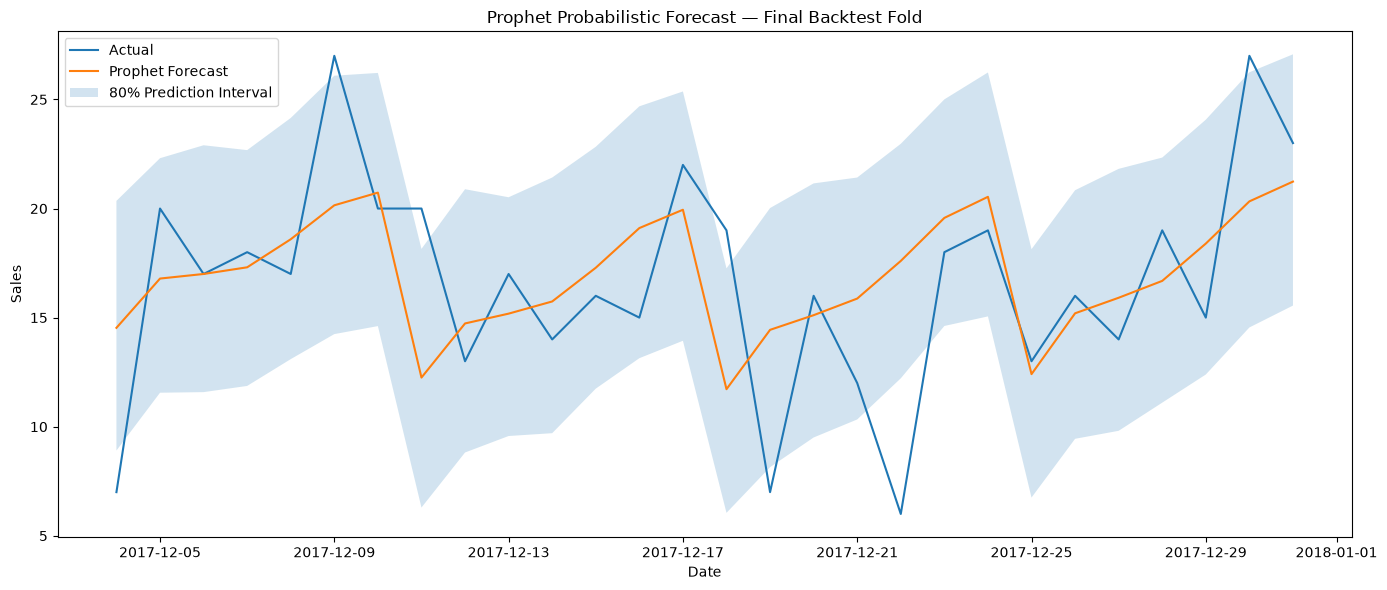

In [59]:
last_prophet_fold = (
    prophet_prob[
        prophet_prob["fold"] == 6
    ]
)

plt.figure(
    figsize=(14, 6)
)

plt.plot(
    last_prophet_fold["date"],
    last_prophet_fold["actual"],
    label="Actual"
)

plt.plot(
    last_prophet_fold["date"],
    last_prophet_fold[
        "point_forecast"
    ],
    label="Prophet Forecast"
)

plt.fill_between(
    last_prophet_fold["date"],
    last_prophet_fold["lower"],
    last_prophet_fold["upper"],
    alpha=0.2,
    label="80% Prediction Interval"
)

plt.title(
    "Prophet Probabilistic Forecast — Final Backtest Fold"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.tight_layout()
plt.show()

## 6.4 Probabilistic Forecast Results

Both Prophet and the sktime Theta forecaster were evaluated using
nominal 80% prediction intervals across six 28-day expanding-window
backtesting folds.

This produced 168 out-of-sample observations for interval evaluation.

The results were:

| Method | Nominal Coverage | Empirical Coverage | Average Width |
|---|---:|---:|---:|
| Prophet | 80% | 75% | 11.328 |
| sktime Theta | 80% | 75% | 12.757 |

Both methods achieved empirical coverage below the nominal 80% target.
This indicates slight under-coverage: the prediction intervals were
somewhat too narrow to contain the intended proportion of future
observations.

Prophet and sktime achieved identical empirical coverage, but Prophet
produced narrower intervals on average. Prophet's intervals were
approximately 1.43 sales units narrower than the sktime intervals.

Therefore, within this particular interval comparison, Prophet provided
greater sharpness while maintaining the same observed coverage.

However, neither method achieved perfect calibration, and these results
are based on a finite sample of 168 out-of-sample forecasts.

## 6.5 Conformal Prediction

Conformal prediction provides a distribution-free alternative for
constructing prediction intervals.

Instead of assuming a particular probability distribution for future
forecast errors, conformal methods use previously observed forecast
errors to calibrate the size of the prediction interval.

This can be useful when the underlying forecast-error distribution is
unknown or when parametric interval assumptions are difficult to
justify.

For time-series forecasting, conformal calibration must still respect
chronological ordering. Future validation observations must not be used
to calibrate intervals for forecasts made earlier in time.

Conformal prediction was considered as an alternative uncertainty
framework in this project, while Prophet and sktime were used for the
primary measured interval comparison.

# 7. Model Comparison and Final Decision

The forecasting approaches are compared using more than a single
accuracy statistic.

The final decision considers:

- out-of-sample MAE and RMSE;
- MASE;
- variation in performance across backtesting folds;
- expanding versus rolling training windows;
- ability to represent seasonal structure;
- interpretability;
- prediction-interval capability;
- and computational and implementation complexity.

The seasonal-naive model is retained as a benchmark rather than as a
candidate advanced modelling family.

In [60]:
final_model_comparison = (
    summary_scores[
        summary_scores["window_type"] == "expanding"
    ]
    [
        [
            "model",
            "window_type",
            "MAE_mean",
            "RMSE_mean",
            "MASE_mean",
            "MAE_std",
            "RMSE_std"
        ]
    ]
    .rename(
        columns={
            "model": "Model",
            "window_type": "Window",
            "MAE_mean": "MAE",
            "RMSE_mean": "RMSE",
            "MASE_mean": "MASE",
            "MAE_std": "MAE_std",
            "RMSE_std": "RMSE_std"
        }
    )
    .sort_values("MAE")
    .reset_index(drop=True)
)

final_model_comparison

,Model,Window,MAE,RMSE,MASE,MAE_std,RMSE_std
0,LightGBM,expanding,4.110350,5.040470,0.841201,0.349819,0.351852
1,SARIMAX,expanding,4.393377,5.248226,0.898983,0.752579,0.883167
2,Exponential Smoothing,expanding,4.469207,5.347645,0.914527,0.624029,0.746899
3,Seasonal Naive,expanding,5.875000,7.081768,1.202505,0.853489,0.808695


## 7.1 Point-Forecast Comparison

The expanding-window walk-forward results provide a common
out-of-sample basis for comparing the principal point-forecast models.

The results were:

| Model | MAE | RMSE | MASE |
|---|---:|---:|---:|
| LightGBM | 4.110 | 5.040 | 0.841 |
| SARIMAX | 4.393 | 5.248 | 0.899 |
| Exponential Smoothing | 4.469 | 5.348 | 0.915 |
| Seasonal Naive | 5.875 | 7.082 | 1.203 |

LightGBM achieved the lowest average MAE and RMSE of the evaluated
point-forecast models.

Relative to the seasonal-naive benchmark, LightGBM reduced average MAE
by approximately 30.0% and average RMSE by approximately 28.8%.

LightGBM also produced the lowest fold-to-fold variation in MAE among
the evaluated point models, with an MAE standard deviation of
approximately 0.350.

SARIMAX and exponential smoothing both improved substantially upon the
seasonal-naive benchmark, demonstrating that the structured weekly
dependence identified during the diagnostic analysis contained useful
forecasting information.

## 7.3 Final Model Decision

For point forecasting, the preferred model for this series is the
**expanding-window LightGBM model**.

This decision is based on out-of-sample walk-forward evidence rather
than in-sample fit.

LightGBM achieved:

- **MAE:** 4.110
- **RMSE:** 5.040
- **MASE:** 0.841
- **MAE standard deviation across folds:** 0.350

It produced the lowest average MAE and RMSE among the evaluated
point-forecast models and showed relatively stable performance across
the six historical forecast periods.

Its performance indicates that combining lagged demand, rolling demand
statistics, and calendar information provided additional predictive
value beyond the weekly seasonal pattern alone.

SARIMAX remains attractive when statistical interpretability and an
explicit representation of autoregressive and seasonal structure are
important. Exponential smoothing provides a simpler classical
alternative with competitive accuracy and relatively low modelling
complexity.

Prophet and sktime served an additional role by representing forecast
uncertainty. Prophet achieved the same empirical interval coverage as
sktime Theta while producing narrower intervals in this evaluation.

Therefore, the project selects LightGBM as the preferred point-forecast
model, while probabilistic methods remain useful when a decision
requires an explicit representation of forecast uncertainty.

# 8. Limitations

This project evaluates a single store-item series from a substantially
larger retail dataset. The forecasting conclusions should therefore not
automatically be assumed to generalise to every store and item.

The models primarily use historical sales and calendar information.
Potential demand drivers such as price, promotions, inventory
availability, holidays, competitor behaviour, weather, and broader
economic conditions are not included.

LightGBM multi-step forecasts are generated recursively. Predictions
from earlier forecast steps may therefore influence features used at
later forecast horizons, allowing forecast errors to accumulate.

The annual seasonal pattern was identified during exploratory analysis,
but the classical SARIMAX implementation explicitly models the weekly
seasonal period rather than a 365-day seasonal state because of the
additional computational complexity of a large seasonal period.

The probabilistic forecasts also showed empirical coverage of 75%
against a nominal target of 80%, indicating some under-coverage.

Finally, historical backtesting estimates how the models would have
performed during the observed period. Future performance may change if
the underlying demand-generating process changes.